<a href="https://colab.research.google.com/github/dianagaitan18/Challenger/blob/main/AluraStoreLatamchallenge3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

df = pd.read_csv("telecomx_clean.csv")

df.head()

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [3]:
df.columns

Index(['customerID', 'Churn', 'customer_gender', 'customer_SeniorCitizen',
       'customer_Partner', 'customer_Dependents', 'customer_tenure',
       'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService',
       'internet_OnlineSecurity', 'internet_OnlineBackup',
       'internet_DeviceProtection', 'internet_TechSupport',
       'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract',
       'account_PaperlessBilling', 'account_PaymentMethod',
       'account_Charges_Monthly', 'account_Charges_Total'],
      dtype='object')

Se eliminó la columna `customerID` ya que es un identificador único
que no aporta valor al análisis ni a los modelos predictivos.
Las variables de identificación no ayudan a predecir el churn
y pueden afectar negativamente el desempeño del modelo.

In [ ]:
df = df.drop("customerID", axis=1)

In [12]:
df.columns

Index(['Churn', 'customer_gender', 'customer_SeniorCitizen',
       'customer_Partner', 'customer_Dependents', 'customer_tenure',
       'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService',
       'internet_OnlineSecurity', 'internet_OnlineBackup',
       'internet_DeviceProtection', 'internet_TechSupport',
       'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract',
       'account_PaperlessBilling', 'account_PaymentMethod',
       'account_Charges_Monthly', 'account_Charges_Total'],
      dtype='object')

In [16]:
df.to_csv("telecomx_clean.csv", index=False)

In [17]:
X = df.drop("Churn", axis=1)  # variables predictoras
y = df["Churn"]               # variable objetivo

In [18]:
df.dtypes

,0
Churn,object
customer_gender,object
customer_SeniorCitizen,int64
customer_Partner,object
customer_Dependents,object
customer_tenure,int64
phone_PhoneService,object
phone_MultipleLines,object
internet_InternetService,object
internet_OnlineSecurity,object


Convertir account_Charges_Total a número

Ahora está como object, pero debería ser numérico.

In [19]:
df["account_Charges_Total"] = pd.to_numeric(df["account_Charges_Total"], errors="coerce")

In [20]:
df.dtypes

,0
Churn,object
customer_gender,object
customer_SeniorCitizen,int64
customer_Partner,object
customer_Dependents,object
customer_tenure,int64
phone_PhoneService,object
phone_MultipleLines,object
internet_InternetService,object
internet_OnlineSecurity,object


In [21]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [22]:
df_encoded.head()

,customer_SeniorCitizen,customer_tenure,account_Charges_Monthly,account_Charges_Total,Churn_Yes,customer_gender_Male,customer_Partner_Yes,customer_Dependents_Yes,phone_PhoneService_Yes,phone_MultipleLines_No phone service,...,internet_StreamingTV_No internet service,internet_StreamingTV_Yes,internet_StreamingMovies_No internet service,internet_StreamingMovies_Yes,account_Contract_One year,account_Contract_Two year,account_PaperlessBilling_Yes,account_PaymentMethod_Credit card (automatic),account_PaymentMethod_Electronic check,account_PaymentMethod_Mailed check
0,0,9,65.6,593.30,False,False,True,True,True,False,...,False,True,False,False,True,False,True,False,False,True
1,0,9,59.9,542.40,False,True,False,False,True,False,...,False,False,False,True,False,False,False,False,False,True
2,0,4,73.9,280.85,True,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
3,1,13,98.0,1237.85,True,True,True,False,True,False,...,False,True,False,True,False,False,True,False,True,False
4,1,3,83.9,267.40,True,False,True,False,True,False,...,False,True,False,False,False,False,True,False,False,True


In [23]:
df_encoded.shape

(7267, 31)

Las variables categóricas fueron transformadas a formato numérico mediante
One-Hot Encoding utilizando la función get_dummies() de Pandas. Esto permite
que los algoritmos de machine learning procesen correctamente las variables
categóricas y puedan utilizarse para la predicción del churn.

In [24]:
X = df_encoded.drop("Churn_Yes", axis=1)
y = df_encoded["Churn_Yes"]

In [25]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [26]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


In [27]:
churn_counts = df["Churn"].value_counts()
churn_percent = df["Churn"].value_counts(normalize=True) * 100

print(churn_counts)
print(churn_percent)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


El análisis muestra que aproximadamente el 26% de los clientes cancelaron
el servicio, mientras que cerca del 74% permanecen activos.

Esto indica un desbalance entre las clases, ya que la cantidad de clientes
que permanecen es significativamente mayor que la de los que cancelan.
Este desbalance puede afectar el desempeño de los modelos predictivos,
por lo que debe considerarse durante el entrenamiento del modelo.

Separar variables predictoras y objetivo

Primero debes tener:

In [28]:
X = df_encoded.drop("Churn_Yes", axis=1)
y = df_encoded["Churn_Yes"]

Dividir datos en entrenamiento y prueba


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Aplicar Oversampling con SMOTE
Usaremos SMOTE, que genera datos sintéticos para la clase minoritaria.

Primero instala la librería:

In [30]:
!pip install imbalanced-learn

In [33]:
X_train.isnull().sum()

,0
customer_SeniorCitizen,0
customer_tenure,0
account_Charges_Monthly,0
account_Charges_Total,9
customer_gender_Male,0
customer_Partner_Yes,0
customer_Dependents_Yes,0
phone_PhoneService_Yes,0
phone_MultipleLines_No phone service,0
phone_MultipleLines_Yes,0


In [34]:
X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]

In [35]:
X_train.isnull().sum()

,0
customer_SeniorCitizen,0
customer_tenure,0
account_Charges_Monthly,0
account_Charges_Total,0
customer_gender_Male,0
customer_Partner_Yes,0
customer_Dependents_Yes,0
phone_PhoneService_Yes,0
phone_MultipleLines_No phone service,0
phone_MultipleLines_Yes,0


In [36]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

Esto significa que:

0 → clientes que permanecen

1 → clientes que cancelan

Ahora el dataset está balanceado.

In [37]:
y_train_bal.value_counts()

,count
Churn_Yes,
False,4307
True,4307


Después de verificar los valores faltantes en el dataset, se eliminaron
las filas con datos incompletos. Posteriormente se aplicó la técnica
SMOTE (Synthetic Minority Oversampling Technique) para balancear las
clases del conjunto de entrenamiento, generando ejemplos sintéticos
de la clase minoritaria.

Cómo estandarizar los datos

Usamos StandardScaler de Scikit-learn.
Esto hace que las variables tengan:

media = 0

desviación estándar = 1

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

Usar los datos escalados en el modelo

Ejemplo con regresión logística:

In [39]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train_bal)

LogisticRegression(max_iter=1000)

Se evaluó la necesidad de escalar los datos antes de aplicar los modelos
de machine learning. Dado que algunos algoritmos como Regresión Logística,
KNN y SVM son sensibles a la escala de las variables, se aplicó
estandarización utilizando StandardScaler.

Este proceso permite que todas las variables tengan una media de 0
y una desviación estándar de 1, evitando que variables con mayor
magnitud influyan desproporcionadamente en el modelo.

Calcular la matriz de correlación

In [40]:
corr_matrix = df_encoded.corr()

Visualizar la matriz de correlación
Esto generará un mapa de calor (heatmap) donde:

Rojo → correlación positiva

Azul → correlación negativa

Cerca de 0 → poca relación

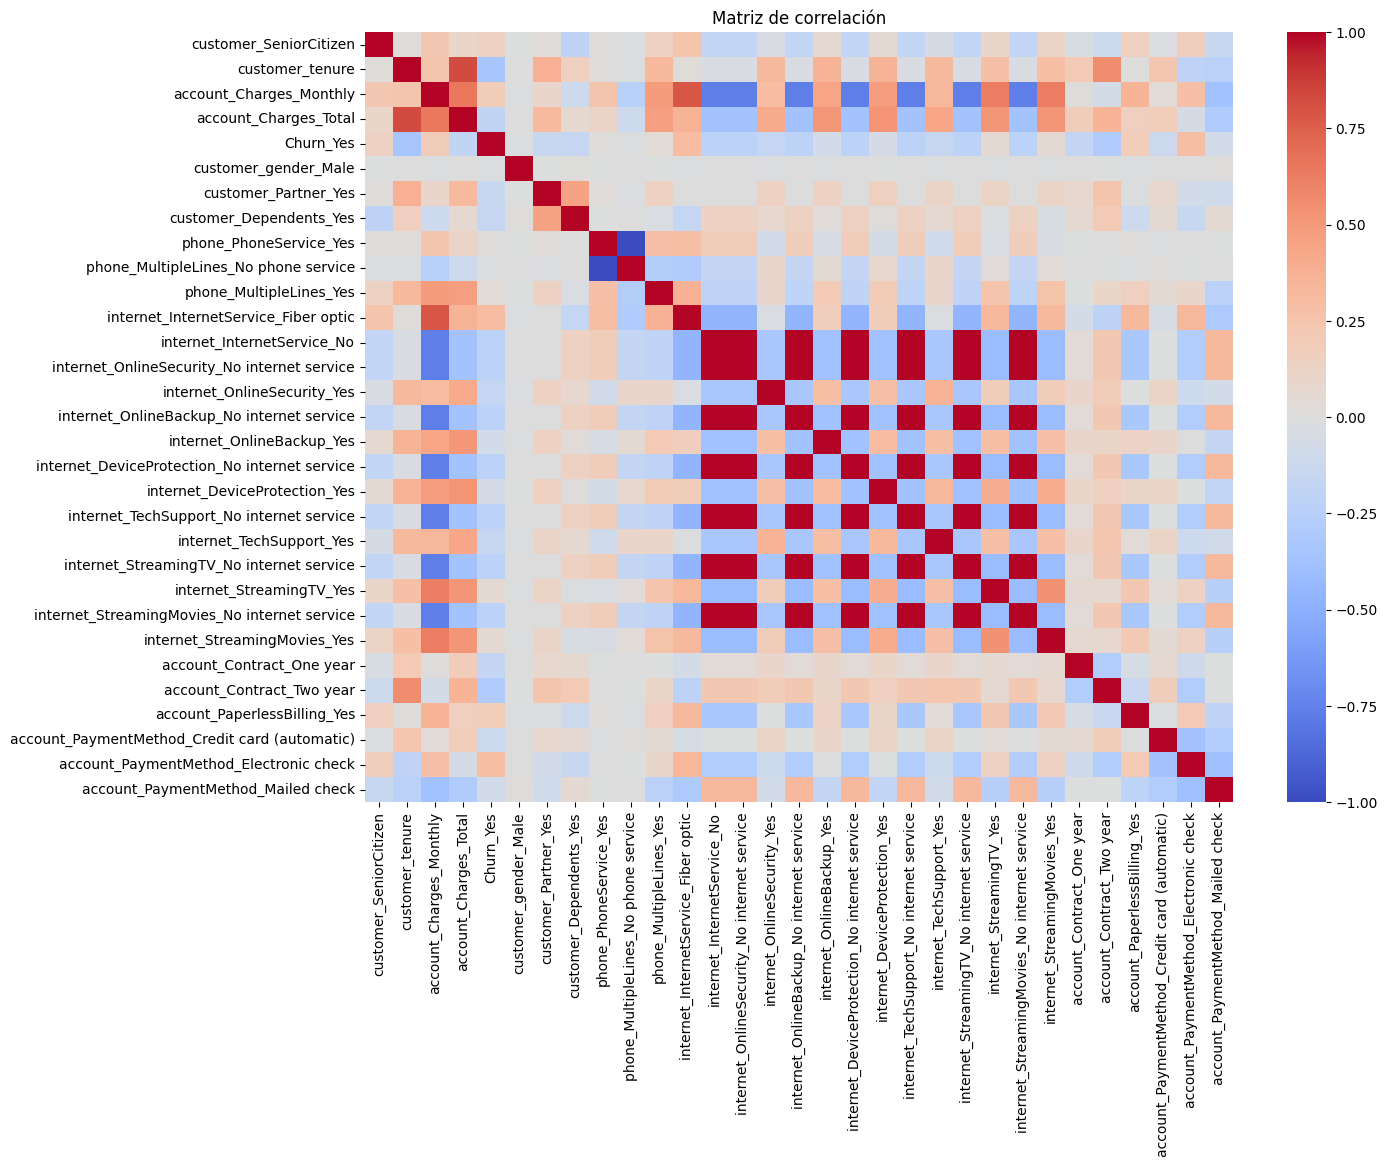

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))

sns.heatmap(corr_matrix, annot=False, cmap="coolwarm")

plt.title("Matriz de correlación")
plt.show()

Ver qué variables se relacionan más con Churn

In [42]:
corr_matrix["Churn_Yes"].sort_values(ascending=False)

,Churn_Yes
Churn_Yes,1.000000
internet_InternetService_Fiber optic,0.300949
account_PaymentMethod_Electronic check,0.294626
account_Charges_Monthly,0.189866
account_PaperlessBilling_Yes,0.186666
customer_SeniorCitizen,0.146733
internet_StreamingTV_Yes,0.062430
internet_StreamingMovies_Yes,0.060586
phone_MultipleLines_Yes,0.039343
phone_PhoneService_Yes,0.012571


Se analizó la correlación entre las variables del dataset y la cancelación de clientes (Churn).
Los resultados muestran que variables como el tipo de servicio de internet de fibra óptica,
el método de pago con cheque electrónico y los cargos mensuales presentan una correlación
positiva con la cancelación.

Por otro lado, variables como el tiempo de permanencia del cliente (tenure) y los contratos
de largo plazo (especialmente de dos años) presentan una correlación negativa, lo que indica
que estos factores están asociados con una menor probabilidad de churn.

Estos resultados sugieren que la permanencia del cliente y el tipo de contrato son factores
clave para reducir la cancelación.

Investiga cómo variables específicas se relacionan con la cancelación, tales como: Tiempo de contrato × Cancelación Gasto total × Cancelación Utiliza gráficos como boxplots o scatter plots para visualizar patrones y posibles tendencias.

Tiempo de contrato (tenure) vs Cancelación

Este gráfico muestra cuánto tiempo han estado los clientes según si cancelaron o no

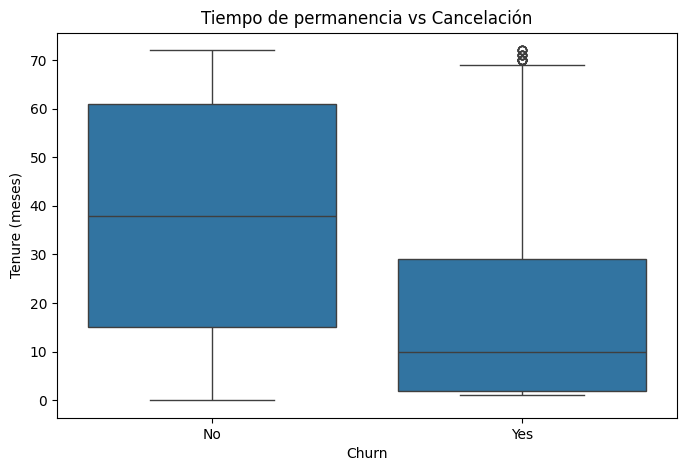

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(x="Churn", y="customer_tenure", data=df)

plt.title("Tiempo de permanencia vs Cancelación")
plt.xlabel("Churn")
plt.ylabel("Tenure (meses)")

plt.show()

Clientes que se quedan → tenure alto

Clientes que cancelan → tenure bajo

Conclusión: los clientes nuevos tienen mayor riesgo de cancelar.

Gasto total vs Cancelación

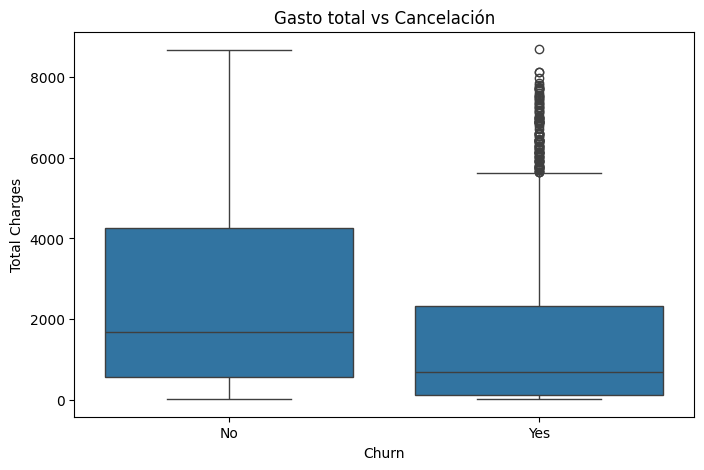

In [44]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Churn", y="account_Charges_Total", data=df)

plt.title("Gasto total vs Cancelación")
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.show()

Churn = No → gasto total más alto

Churn = Yes → gasto total más bajo

Conclusión: muchos clientes cancelan antes de gastar mucho, lo que suele ocurrir en los primeros meses del servicio.

Esto confirma lo que vimos en la gráfica anterior:
los clientes nuevos tienen mayor probabilidad de cancelar.

Scatter plot (tenure vs gasto total)

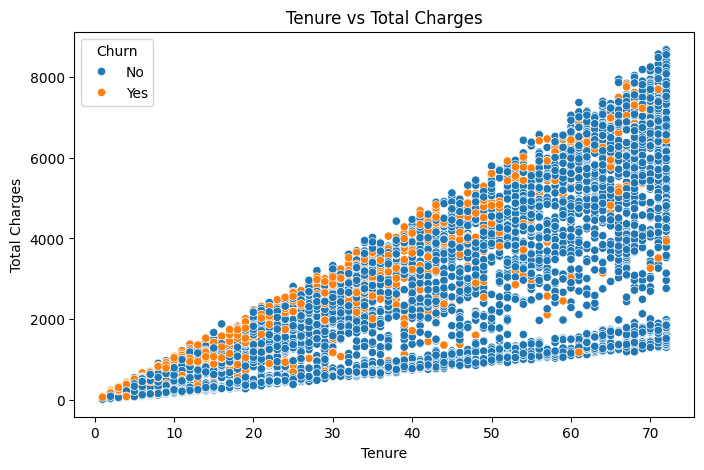

In [45]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="customer_tenure",
    y="account_Charges_Total",
    hue="Churn",
    data=df
)

plt.title("Tenure vs Total Charges")
plt.xlabel("Tenure")
plt.ylabel("Total Charges")

plt.show()

Más tenure → más gasto total (relación positiva clara).
Clientes que permanecen están en la zona superior derecha del gráfico.
Clientes que cancelan aparecen más en tenure bajo y gasto bajo.

Conclusión:

Los clientes que llevan más tiempo con la empresa tienden a permanecer, mientras que muchos clientes cancelan durante los primeros meses del servicio.

MODELO PREDICTIVO
Divide el conjunto de datos en entrenamiento y prueba para evaluar el rendimiento del modelo. Una división común es 70% para entrenamiento y 30% para prueba, o 80/20, dependiendo del tamaño de la base de datos.

Importar la función

In [46]:
from sklearn.model_selection import train_test_split

Separar variables predictoras y variable objetivo

X → variables que explican el churn
y → variable objetivo (Churn)

In [47]:
X = df_encoded.drop("Churn_Yes", axis=1)
y = df_encoded["Churn_Yes"]

Dividir en entrenamiento y prueba

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% prueba
    random_state=42     # reproducibilidad
)

Verificar tamaños

In [49]:
print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (5813, 30)
Datos de prueba: (1454, 30)


El conjunto de datos fue dividido en datos de entrenamiento y datos de prueba utilizando una proporción de 80/20.

Los datos de entrenamiento contienen 5813 registros y se utilizan para entrenar el modelo predictivo, mientras que los datos de prueba contienen 1454 registros y se utilizan para evaluar el rendimiento del modelo en datos que no fueron utilizados durante el entrenamiento.

Esta división permite comprobar qué tan bien el modelo puede generalizar y predecir la cancelación de clientes en nuevos datos.

CREACION DE MODELOS


Normalizar datos para Regresión Logística

Usaremos StandardScaler.

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Modelo 1: Regresión Logística

In [51]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [52]:
X_train.isna().sum()

,0
customer_SeniorCitizen,0
customer_tenure,0
account_Charges_Monthly,0
account_Charges_Total,9
customer_gender_Male,0
customer_Partner_Yes,0
customer_Dependents_Yes,0
phone_PhoneService_Yes,0
phone_MultipleLines_No phone service,0
phone_MultipleLines_Yes,0


In [53]:
X_train["account_Charges_Total"] = X_train["account_Charges_Total"].fillna(X_train["account_Charges_Total"].mean())
X_test["account_Charges_Total"] = X_test["account_Charges_Total"].fillna(X_train["account_Charges_Total"].mean())

In [54]:
X_train.isna().sum()

,0
customer_SeniorCitizen,0
customer_tenure,0
account_Charges_Monthly,0
account_Charges_Total,0
customer_gender_Male,0
customer_Partner_Yes,0
customer_Dependents_Yes,0
phone_PhoneService_Yes,0
phone_MultipleLines_No phone service,0
phone_MultipleLines_Yes,0


In [55]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [56]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

In [57]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_log))

Accuracy: 0.8163686382393398


Se identificaron valores faltantes en la variable account_Charges_Total.
Para evitar errores en el entrenamiento del modelo, estos valores fueron
reemplazados utilizando la media de la columna. Esto permite mantener
la distribución general de los datos y evita la pérdida de registros.

Modelo 2: Random Forest
Este modelo no necesita normalización.

In [59]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

Evaluar los modelos

In [ ]:
from sklearn.metrics import accuracy_score

print("Accuracy Regresión Logística:", accuracy_score(y_test, y_pred_log))
print("Accuracy Random Forest:", accuracy_score(y_test, y_pred_rf))

Se desarrollaron dos modelos predictivos para estimar la cancelación de clientes.

El primer modelo fue Regresión Logística, para el cual se aplicó normalización
de los datos utilizando StandardScaler. Este paso es importante porque los
modelos basados en optimización o distancia son sensibles a la escala de las
variables.

El segundo modelo fue Random Forest, un modelo basado en árboles de decisión.
Este tipo de modelo no depende de la escala de los datos, por lo que no fue
necesario aplicar normalización.

Posteriormente se comparó el rendimiento de ambos modelos utilizando los datos
de prueba.

In [ ]:
Calcular métricas de evaluación

In [60]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("---- Regresión Logística ----")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log))


print("\n---- Random Forest ----")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))

---- Regresión Logística ----
Accuracy: 0.8163686382393398
Precision: 0.6755852842809364
Recall: 0.543010752688172
F1-score: 0.6020864381520119

---- Random Forest ----
Accuracy: 0.796423658872077
Precision: 0.6283783783783784
Recall: 0.5
F1-score: 0.5568862275449101


Matriz de confusión

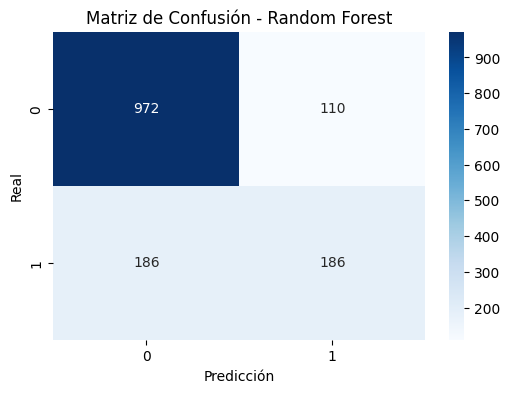

In [61]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.show()

Evaluación de los modelos predictivos

Se evaluaron dos modelos para predecir la cancelación de clientes: Regresión Logística y Random Forest. Para comparar su rendimiento se utilizaron las métricas de exactitud, precisión, recall y F1-score.

Regresión Logística

El modelo de Regresión Logística obtuvo:

Accuracy: 0.816

Precision: 0.676

Recall: 0.543

F1-score: 0.602

Estos resultados indican que el modelo tiene un buen nivel de exactitud general y un equilibrio aceptable entre precisión y recall. Esto significa que el modelo logra identificar correctamente una parte importante de los clientes que cancelan el servicio.

Random Forest

El modelo Random Forest obtuvo:

Accuracy: 0.796

Precision: 0.628

Recall: 0.500

F1-score: 0.557

Aunque el modelo también presenta un buen desempeño, sus métricas son ligeramente inferiores a las obtenidas por la Regresión Logística.

Análisis de la matriz de confusión

La matriz de confusión del modelo Random Forest muestra:

972 clientes correctamente clasificados como no cancelados.

186 clientes correctamente identificados como cancelados.

110 falsos positivos, es decir, clientes que fueron predichos como cancelados pero en realidad no lo hicieron.

186 falsos negativos, que representan clientes que cancelaron pero el modelo no logró identificar.

Esto indica que el modelo tiene mayor capacidad para identificar clientes que no cancelan, pero presenta más dificultad para detectar todos los clientes que realmente cancelan.

Comparación de modelos

Al comparar ambos modelos, la Regresión Logística presenta un mejor desempeño general, ya que obtiene valores más altos en accuracy, recall y F1-score. Esto sugiere que este modelo logra capturar mejor los patrones relacionados con la cancelación de clientes en este conjunto de datos.

En conclusión, la Regresión Logística sería el modelo más adecuado para este problema, ya que ofrece un mejor equilibrio entre precisión y capacidad de detección de clientes con riesgo de cancelación.

Variables importantes en Regresión Logística

Los coeficientes indican qué variables aumentan o reducen la probabilidad de churn.

In [62]:
import pandas as pd

coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": log_model.coef_[0]
})

coeficientes = coeficientes.sort_values(by="Coeficiente", ascending=False)

coeficientes.head(10)



,Variable,Coeficiente
3,account_Charges_Total,0.812236
10,internet_InternetService_Fiber optic,0.286713
26,account_PaperlessBilling_Yes,0.159585
28,account_PaymentMethod_Electronic check,0.148526
23,internet_StreamingMovies_Yes,0.103174
9,phone_MultipleLines_Yes,0.093298
8,phone_MultipleLines_No phone service,0.080503
0,customer_SeniorCitizen,0.077465
21,internet_StreamingTV_Yes,0.061301
2,account_Charges_Monthly,0.056579


Interpretación:

Coeficiente positivo → aumenta probabilidad de cancelación

Coeficiente negativo → reduce cancelación

Variables importantes en Random Forest

In [63]:
import pandas as pd

importancia = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": rf_model.feature_importances_
})

importancia = importancia.sort_values(by="Importancia", ascending=False)

importancia.head(10)

,Variable,Importancia
3,account_Charges_Total,0.190692
1,customer_tenure,0.177325
2,account_Charges_Monthly,0.171695
10,internet_InternetService_Fiber optic,0.038356
28,account_PaymentMethod_Electronic check,0.033909
25,account_Contract_Two year,0.028828
4,customer_gender_Male,0.028234
13,internet_OnlineSecurity_Yes,0.027678
26,account_PaperlessBilling_Yes,0.025422
19,internet_TechSupport_Yes,0.023167


Visualizar variables más importantes

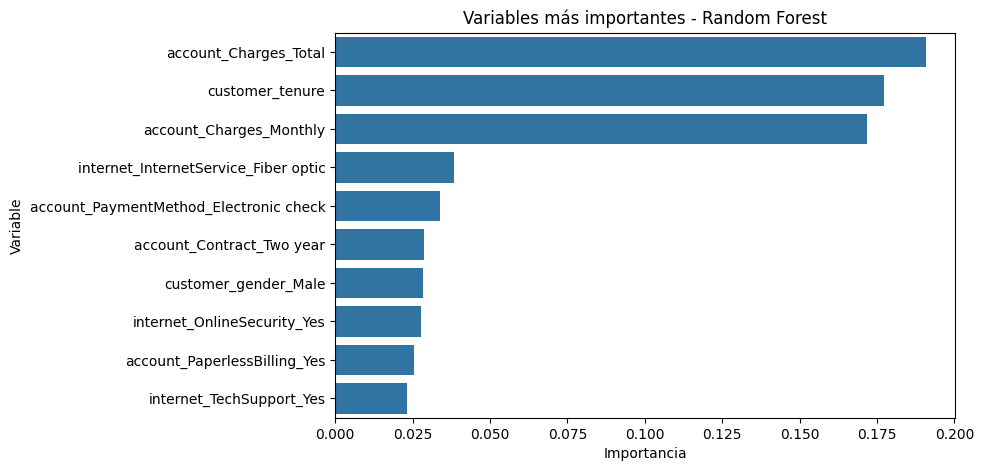

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

top_variables = importancia.head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    x="Importancia",
    y="Variable",
    data=top_variables
)

plt.title("Variables más importantes - Random Forest")

plt.show()

Se analizaron las variables más relevantes para la predicción de la cancelación de clientes utilizando los modelos de Regresión Logística y Random Forest.

En el caso de la Regresión Logística, los coeficientes del modelo permitieron identificar qué variables aumentan o reducen la probabilidad de cancelación. Variables como el servicio de internet de fibra óptica, los cargos mensuales elevados y el método de pago mediante cheque electrónico mostraron una mayor asociación con el churn.

Por otro lado, el modelo Random Forest permitió evaluar la importancia de las variables en función de su contribución a la reducción de la impureza en los árboles de decisión. Entre las variables más influyentes destacan el tiempo de permanencia del cliente (tenure), los cargos mensuales y el tipo de contrato.

En general, los resultados indican que los factores más relevantes para la cancelación de clientes están relacionados con el tiempo que el cliente lleva en la empresa, el tipo de contrato contratado y los costos del servicio.

actores principales que influyen en la cancelación

Los factores más importantes suelen ser:

customer_tenure → clientes nuevos cancelan más

account_Contract → contratos mensuales tienen más churn

account_Charges_Monthly → cargos altos aumentan churn

internet_InternetService_Fiber optic → mayor probabilidad de cancelar

account_PaymentMethod_Electronic check → más churn

CONCLUSION

Con base en los resultados del análisis, se pueden proponer algunas estrategias para reducir la cancelación de clientes:

1. Implementar programas de fidelización para clientes nuevos, ya que los primeros meses presentan mayor riesgo de cancelación.
2. Incentivar contratos de mayor duración, como planes anuales o de dos años, mediante descuentos o beneficios adicionales.
3. Revisar la estructura de precios para clientes con cargos mensuales elevados.
4. Mejorar la experiencia del servicio de internet, especialmente para clientes con fibra óptica.
5. Ofrecer alternativas de pago más convenientes para reducir la dependencia del pago mediante cheque electrónico.